Variable analizada: edad
Media:    35.0
Mediana:  35.0
Moda:     20
Desv.est: 10.801234497346433


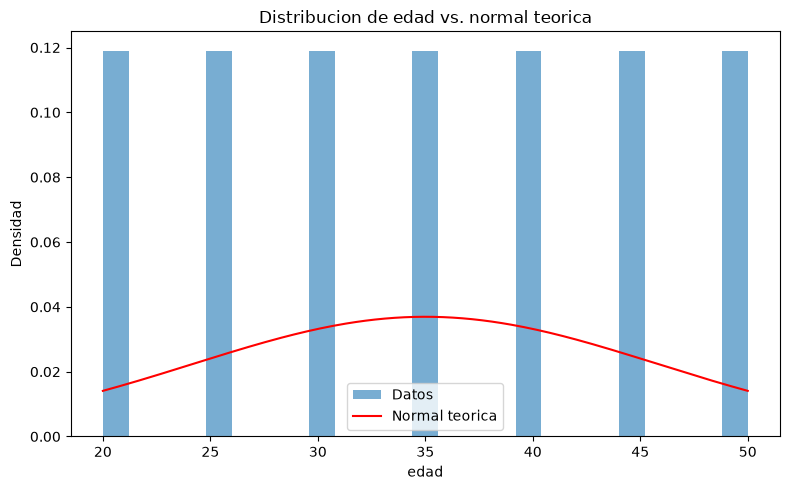

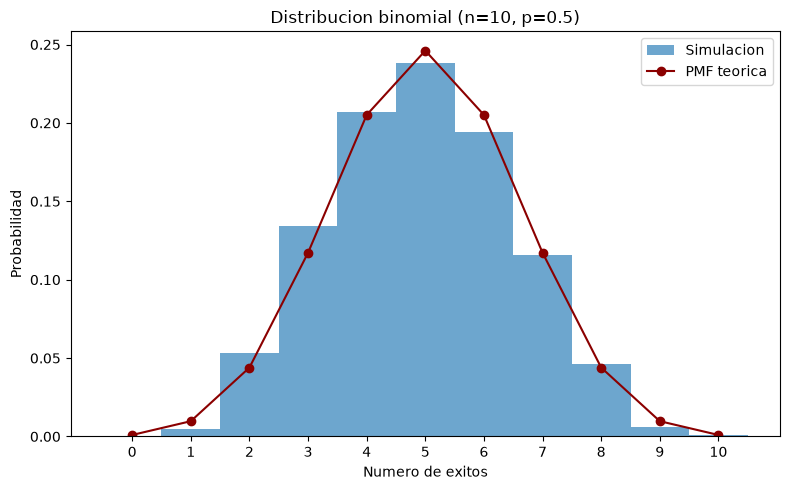

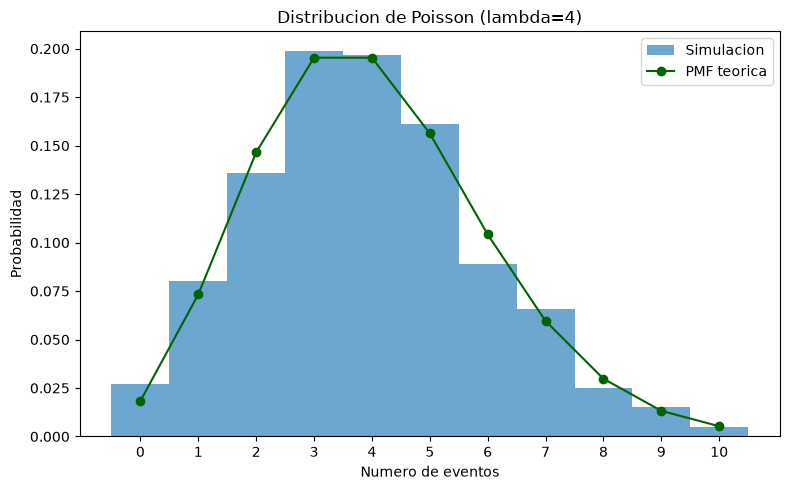

P(spam | contiene 'gratis') = 0.842


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Carga del dataset y seleccion de una variable numerica
df = pd.read_csv("mi_dataset.csv")
col = df.select_dtypes("number").columns[0]
datos = df[col].dropna()

# 1) Estadistica descriptiva
print("Variable analizada:", col)
print("Media:   ", datos.mean())
print("Mediana: ", datos.median())
print("Moda:    ", datos.mode()[0])
print("Desv.est:", datos.std())

# 2) Histograma con curva normal teorica
media = datos.mean()
desviacion = datos.std()
x = np.linspace(datos.min(), datos.max(), 200)
plt.figure(figsize=(8, 5))
plt.hist(datos, bins=25, density=True, alpha=.6, label="Datos")
plt.plot(x, stats.norm.pdf(x, media, desviacion), "r-", label="Normal teorica")
plt.title(f"Distribucion de {col} vs. normal teorica")
plt.xlabel(col)
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Simulacion y grafica de una distribucion binomial
n = 10
p = 0.5
muestras_binomial = stats.binom.rvs(n, p, size=1000, random_state=42)
valores_binomial = np.arange(n + 1)
probabilidades_binomial = stats.binom.pmf(valores_binomial, n, p)

plt.figure(figsize=(8, 5))
plt.hist(muestras_binomial, bins=np.arange(-.5, n + 1.5, 1), density=True,
         alpha=.65, label="Simulacion")
plt.plot(valores_binomial, probabilidades_binomial, "o-", color="darkred",
         label="PMF teorica")
plt.title(f"Distribucion binomial (n={n}, p={p})")
plt.xlabel("Numero de exitos")
plt.ylabel("Probabilidad")
plt.xticks(valores_binomial)
plt.legend()
plt.tight_layout()
plt.show()

# 4) Simulacion y grafica de una distribucion de Poisson
lam = 4
muestras_poisson = stats.poisson.rvs(lam, size=1000, random_state=42)
valores_poisson = np.arange(0, muestras_poisson.max() + 1)
probabilidades_poisson = stats.poisson.pmf(valores_poisson, lam)

plt.figure(figsize=(8, 5))
plt.hist(muestras_poisson, bins=np.arange(-.5, muestras_poisson.max() + 1.5, 1),
         density=True, alpha=.65, label="Simulacion")
plt.plot(valores_poisson, probabilidades_poisson, "o-", color="darkgreen",
         label="PMF teorica")
plt.title(f"Distribucion de Poisson (lambda={lam})")
plt.xlabel("Numero de eventos")
plt.ylabel("Probabilidad")
plt.xticks(valores_poisson)
plt.legend()
plt.tight_layout()
plt.show()

# 5) Mini clasificador de spam con el teorema de Bayes
# P(spam)=0.4, P(gratis|spam)=0.8, P(gratis|no_spam)=0.1
p_spam = 0.4
p_gratis_dado_spam = 0.8
p_gratis_dado_no = 0.1
p_no_spam = 1 - p_spam

p_gratis = (p_gratis_dado_spam * p_spam
            + p_gratis_dado_no * p_no_spam)
p_spam_dado_gratis = (p_gratis_dado_spam * p_spam) / p_gratis
print(f"P(spam | contiene 'gratis') = {p_spam_dado_gratis:.3f}")
